# Basic

In [1]:
%load_ext autoreload
%autoreload all

In [ ]:
import polars as pl
import seaborn as sns
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.ticker import PercentFormatter
from tqdm import tqdm
import glob
import pickle

import src.graph_tokenizer_gd_tree_dev.config as config
import src.graph_tokenizer_gd_tree_dev.graph_fct as graph_fct
import src.graph_tokenizer_gd_tree_dev.tokenizer as tokenizer
import src.graph_tokenizer_gd_tree_dev.utils as utils



# get vocabs

df_vocab_freq = (pl.read_parquet(config.HERODataVocabsTest.vocab_count_volumn)
                 .filter(pl.col("date").dt.year()<2026)
                 .filter(pl.col("coding_system") == "SNOMED")
                 .sort(by = "len", descending=True))


286496776

# analyze the tokenizer

In [46]:
def prepare_subgraph (D:int, mapped_ids: list):
    df_relations = pl.read_parquet(f"{config.BasicConfig().relation_path}")

    # remove root concept
    df_relations = df_relations.filter(~pl.col("dst.id").is_in(config.TokenizerParam().exclude_cpt))

    # build graph and combine
    whole_graph = graph_fct.build_relations_graph(df_relations, col_src="src.id", col_dst="dst.id", col_relation="relation")
    combined_subgraphs = graph_fct.get_combined_subgraphs_from_nodes(whole_graph, mapped_ids, D)
    df_cpt = pl.read_parquet(config.BasicConfig().concept_path).select("id", "label")
    id_to_label = dict(zip(df_cpt["id"], df_cpt["label"]))
    
    return id_to_label, combined_subgraphs


## 1. build subgraph

In [47]:
mapped_ids = df_vocab_freq["code"].unique().to_list()
D = config.TokenizerParam().max_dist_candidate

In [48]:
id_to_label, combined_subgraphs = prepare_subgraph(D = D, mapped_ids = mapped_ids)
with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "wb") as f:
    pickle.dump(id_to_label, f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "wb") as f:
    pickle.dump(combined_subgraphs, f)

combined_subgraphs.number_of_edges(), combined_subgraphs.number_of_nodes(), nx.number_weakly_connected_components(combined_subgraphs)

(134313, 37601, 3)

## 2. greedy selection

In [59]:
with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_freq["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]


lambdas_list = np.round(np.arange(0.6, 1.05, 0.1), 1)


for lam in tqdm(lambdas_list):
    selector = tokenizer.LazyGreedyTokenSelector(combined_subgraphs, mapped_ids_overlap, D = D, lam = lam)
    history = selector.select(k = len(mapped_ids_overlap),n_jobs=-1)   # [(token, marginal_gain, cumulative_score), ...]
    df_history =(
        pl.DataFrame(
        history, schema=["token", "gain", "cumulative_score"], orient="row")
        .with_columns(
        pl.col("token").replace_strict(id_to_label, default=None).alias("label"))
        .with_row_index())
    df_history.write_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{lam}.parquet")

  0%|          | 0/5 [00:00<?, ?it/s]

  seeding candidates: 0/37601  (16 workers)
  seeding candidates: 5000/37601  (16 workers)
  seeding candidates: 10000/37601  (16 workers)
  seeding candidates: 15000/37601  (16 workers)
  seeding candidates: 20000/37601  (16 workers)
  seeding candidates: 25000/37601  (16 workers)
  seeding candidates: 30000/37601  (16 workers)
  seeding candidates: 35000/37601  (16 workers)
  seeding candidates: 37601/37601  (16 workers)
[   1/16370] token='362981000'     gain=0.02640  score=0.02640  opt<=0.04177  (re-evals=1, queue=37600)
[   2/16370] token='129266000'     gain=0.01801  score=0.04442  opt<=0.07027  (re-evals=3, queue=37599)
[   3/16370] token='49755003'      gain=0.01606  score=0.06048  opt<=0.09567  (re-evals=1, queue=37598)
[   4/16370] token='91723000'      gain=0.01041  score=0.07089  opt<=0.11215  (re-evals=2, queue=37597)
[   5/16370] token='404684003'     gain=0.00939  score=0.08029  opt<=0.12701  (re-evals=4, queue=37596)
[   6/16370] token='182353008'     gain=0.00802  scor

 20%|██        | 1/5 [51:17<3:25:08, 3077.15s/it]

  seeding candidates: 0/37601  (16 workers)
  seeding candidates: 5000/37601  (16 workers)
  seeding candidates: 10000/37601  (16 workers)
  seeding candidates: 15000/37601  (16 workers)
  seeding candidates: 20000/37601  (16 workers)
  seeding candidates: 25000/37601  (16 workers)
  seeding candidates: 30000/37601  (16 workers)
  seeding candidates: 35000/37601  (16 workers)
  seeding candidates: 37601/37601  (16 workers)
[   1/16370] token='362981000'     gain=0.05321  score=0.05321  opt<=0.08418  (re-evals=1, queue=37600)
[   2/16370] token='49755003'      gain=0.02729  score=0.08050  opt<=0.12735  (re-evals=4, queue=37599)
[   3/16370] token='91723000'      gain=0.02251  score=0.10301  opt<=0.16296  (re-evals=2, queue=37598)
[   4/16370] token='129266000'     gain=0.01851  score=0.12152  opt<=0.19225  (re-evals=2, queue=37597)
[   5/16370] token='404684003'     gain=0.01586  score=0.13739  opt<=0.21734  (re-evals=4, queue=37596)
[   6/16370] token='105590001'     gain=0.01431  scor

 40%|████      | 2/5 [1:49:02<2:45:16, 3305.37s/it]

...

 60%|██████    | 3/5 [2:54:33<1:59:42, 3591.09s/it]

  seeding candidates: 0/37601  (16 workers)
  seeding candidates: 5000/37601  (16 workers)
  seeding candidates: 10000/37601  (16 workers)
  seeding candidates: 15000/37601  (16 workers)
  seeding candidates: 20000/37601  (16 workers)
  seeding candidates: 25000/37601  (16 workers)
  seeding candidates: 30000/37601  (16 workers)
  seeding candidates: 35000/37601  (16 workers)
  seeding candidates: 37601/37601  (16 workers)
[   1/16370] token='362981000'     gain=0.17928  score=0.17928  opt<=0.28362  (re-evals=1, queue=37600)
[   2/16370] token='123037004'     gain=0.11390  score=0.29319  opt<=0.46382  (re-evals=1, queue=37599)
[   3/16370] token='105590001'     gain=0.05626  score=0.34945  opt<=0.55282  (re-evals=7, queue=37598)
[   4/16370] token='404684003'     gain=0.04109  score=0.39054  opt<=0.61782  (re-evals=2, queue=37597)
[   5/16370] token='91723000'      gain=0.03403  score=0.42456  opt<=0.67165  (re-evals=3, queue=37596)
[   6/16370] token='363787002'     gain=0.02745  scor

 80%|████████  | 4/5 [4:09:55<1:05:58, 3958.76s/it]

  seeding candidates: 0/37601  (16 workers)
  seeding candidates: 5000/37601  (16 workers)
  seeding candidates: 10000/37601  (16 workers)
  seeding candidates: 15000/37601  (16 workers)
  seeding candidates: 20000/37601  (16 workers)
  seeding candidates: 25000/37601  (16 workers)
  seeding candidates: 30000/37601  (16 workers)
  seeding candidates: 35000/37601  (16 workers)
  seeding candidates: 37601/37601  (16 workers)
[   1/16370] token='362981000'     gain=0.30769  score=0.30769  opt<=0.48676  (re-evals=1, queue=37600)
[   2/16370] token='123037004'     gain=0.22959  score=0.53728  opt<=0.84996  (re-evals=1, queue=37599)
[   3/16370] token='105590001'     gain=0.10638  score=0.64366  opt<=1.00000  (re-evals=6, queue=37598)
[   4/16370] token='404684003'     gain=0.06376  score=0.70742  opt<=1.00000  (re-evals=3, queue=37597)
[   5/16370] token='91723000'      gain=0.05028  score=0.75770  opt<=1.00000  (re-evals=1, queue=37596)
[   6/16370] token='363787002'     gain=0.04701  scor

100%|██████████| 5/5 [5:32:59<00:00, 3995.86s/it]  


In [58]:
len(mapped_ids_overlap)

16370

## 3. evaluate metrics

In [60]:
gd_tree_list = glob.glob(config.HERODataVocabsTest.greedy_candidate_path + '/*.parquet')
all_candidates = utils.to_type_dict(gd_tree_list)
mapped_ids = df_vocab_freq["code"].unique().to_list()
D = config.TokenizerParam().max_dist_candidate
print(len(mapped_ids))


with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_freq["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]

Ks = np.arange(2000, 8000, 500)
len(mapped_ids_overlap)


18687


16370

In [61]:
import multiprocessing as mp
import os

results = []
candidate_col = "token"
tasks = []
for category, file in all_candidates.items():
    if category != "0.0": 
        df = pl.read_parquet(file)
        for k in Ks:
            candidates = df.head(k)[candidate_col].to_list()
            tasks.append(((category, k), candidates))

# Built once and shared across every task instead of being rebuilt per (category, file_type, k):
# A/node_to_idx is the semantic-coverage transition matrix, adj is the out-adjacency used by
# context-tree building. Neither depends on the candidate set T, only on the fixed graph.
A, node_to_idx = tokenizer.build_coverage_transition(combined_subgraphs)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

n_workers = os.cpu_count()
with mp.Pool(n_workers, initializer=tokenizer._init_coverage_worker,
             initargs=(A, node_to_idx, adj, mapped_ids_overlap, D, id_to_label)) as pool:
    task_results = pool.imap_unordered(tokenizer._worker_coverage_score, tasks, chunksize=4)
    for (category, k), metrics in tqdm(task_results, total=len(tasks)):
        results.append({
            "category": category,
            "k": k,
            **metrics,
        })

results_df = pl.DataFrame(results)
results_df.write_parquet(config.HERODataVocabsTest().perf_greedy_tree_path)

100%|██████████| 60/60 [02:23<00:00,  2.39s/it] 


In [62]:
pl.read_parquet(config.HERODataVocabsTest().perf_greedy_tree_path)

category,k,conciseness,distance_score,uniqueness_entropy,unk_rate,uncovered_rate,tree_complexity,exact_rate,unique_rate,semantic_coverage
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0.9""",6000,6.594808,0.852609,0.975958,0.011118,0.0,4.4281,0.254856,0.813378,0.999998
"""0.9""",6500,6.136225,0.862538,0.97716,0.009102,0.0,4.192059,0.28485,0.821075,0.999998
"""0.9""",7000,5.704582,0.872602,0.978632,0.007819,0.0,3.96518,0.314233,0.831765,0.999998
"""0.9""",7500,5.278619,0.882027,0.979452,0.007086,0.0,3.740318,0.344349,0.839218,0.999999
"""0.8""",6000,6.717166,0.849061,0.975891,0.016494,0.0,4.513378,0.267135,0.813561,0.999988
…,…,…,…,…,…,…,…,…,…,…
"""0.7""",3500,9.814478,0.783678,0.967537,0.049175,0.0,6.0865,0.131949,0.756139,0.999862
"""0.6""",2000,12.33372,0.726224,0.958081,0.121564,0.0,7.365302,0.059988,0.706659,0.998664
"""0.6""",2500,11.359621,0.746168,0.961926,0.108491,0.0,6.902749,0.086927,0.727123,0.998813


In [63]:
perf_df_all = (pl.read_parquet(config.HERODataVocabsTest().perf_greedy_tree_path)
               .rename({"uncovered_rate": "unknown_rate",
                        "unk_rate": "uncovered_branche_rate"})
               .drop("exact_rate"))

METRIC_CORE = ['conciseness', 'distance_score', 'unique_rate', 'unknown_rate', 'semantic_coverage']


compression_level_dict = {
    "high": [2000, 3500],      # small k, most compression
    "mid":  [4000, 5500],
    "low":  [6000, 7500],   # large k, least compression
}


higher_is_better = {
    "semantic_coverage": True,
    "distance_score": True,
    "unique_rate": True,
    "conciseness": False,
    "unknown_rate": False,
}


# compression rate for each compression level
for compression_level, (k_min, k_max) in compression_level_dict.items():
    print(f"Compression level: {compression_level}, k_min: {k_min}, k_max: {k_max}")
    print(f"compression rate: {k_min/len(mapped_ids):.2%} - {k_max/len(mapped_ids):.2%}")

df_rank_input = (
    perf_df_all
    .select(["category", "k"] + METRIC_CORE)
    .with_columns(
        pl.when(pl.col("k").is_between(*compression_level_dict["high"])).then(pl.lit("high"))
          .when(pl.col("k").is_between(*compression_level_dict["mid"])).then(pl.lit("mid"))
          .when(pl.col("k").is_between(*compression_level_dict["low"])).then(pl.lit("low"))
          .alias("compression_level"))
    .filter(pl.col("compression_level").is_not_null())
)

ranked = (
    df_rank_input
    # rank the λ runs against each other at the same k (rank 1 = best)
    .with_columns([
        pl.col(m).rank(method="average", descending=higher_is_better[m])
          .over("k").alias(f"{m}_rank")
        for m in METRIC_CORE])
    .with_columns(pl.mean_horizontal([f"{m}_rank" for m in METRIC_CORE]).alias("avg_rank"))
)

rank_table = (
    ranked
    # average over the k values in each level
    .group_by(["compression_level", "category"])
    .agg([pl.col(f"{m}_rank").mean() for m in METRIC_CORE]
         + [pl.col("avg_rank").mean()])
    .sort(["compression_level", "avg_rank"])
)

rank_table.write_csv(config.HERODataVocabsTest.rank_perf)



Compression level: high, k_min: 2000, k_max: 3500
compression rate: 10.70% - 18.73%
Compression level: mid, k_min: 4000, k_max: 5500
compression rate: 21.41% - 29.43%
Compression level: low, k_min: 6000, k_max: 7500
compression rate: 32.11% - 40.13%


In [64]:
rank_table


compression_level,category,conciseness_rank,distance_score_rank,unique_rate_rank,unknown_rate_rank,semantic_coverage_rank,avg_rank
str,str,f64,f64,f64,f64,f64,f64
"""high""","""0.9""",1.75,1.0,4.0,3.0,2.0,2.35
"""high""","""0.8""",3.0,2.0,3.0,3.0,3.0,2.8
"""high""","""1.0""",1.5,5.0,5.0,3.0,1.0,3.1
"""high""","""0.7""",3.75,3.0,2.0,3.0,4.0,3.15
"""high""","""0.6""",5.0,4.0,1.0,3.0,5.0,3.6
…,…,…,…,…,…,…,…
"""mid""","""0.9""",1.0,1.0,3.5,3.0,2.0,2.1
"""mid""","""0.8""",2.0,2.0,3.0,3.0,3.0,2.6
"""mid""","""0.7""",3.0,3.0,2.5,3.0,4.0,3.1


In [24]:
hi = perf_df_all.filter(pl.col("category") == "0.9")
hi

category,k,conciseness,distance_score,uniqueness_entropy,uncovered_branche_rate,unknown_rate,tree_complexity,unique_rate,semantic_coverage
str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""0.9""",6000,8.275662,0.84565,0.976078,0.011224,0.0,4.524833,0.813831,0.999998
"""0.9""",6500,7.588136,0.856262,0.977325,0.009354,0.0,4.277955,0.822159,0.999998
"""0.9""",7000,6.935188,0.866643,0.978578,0.007966,0.0,4.044234,0.831453,0.999998
"""0.9""",7500,6.313862,0.876691,0.979461,0.007181,0.0,3.812866,0.839056,0.999998
"""0.9""",2000,20.322008,0.718852,0.95675,0.054312,0.0,7.727234,0.692595,0.999929
…,…,…,…,…,…,…,…,…,…
"""0.9""",3500,13.774908,0.78069,0.96706,0.028665,0.0,6.092994,0.75095,0.999983
"""0.9""",4000,12.237946,0.795629,0.969296,0.022932,0.0,5.691268,0.765796,0.999986
"""0.9""",4500,10.977611,0.810179,0.970911,0.018587,0.0,5.352604,0.778468,0.999994


# tokenize with lamdas and k

In [65]:
import polars as pl
from src.graph_tokenizer_gd_tree_dev.eval import build_context_trees, _iter_contexts

def flat_tokens(tree):
    """All tokens in the tree, relation types ignored (a set: each token once)."""
    return {tok for ctx in _iter_contexts(tree) for tok, _ in ctx.tokens}


with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)


In [28]:
LAMBDA = "0.9"
K = 1000
D = config.TokenizerParam().max_dist_candidate

# 1. once per graph: out-adjacency (non-IS_A edges first, IS_A last)
adj = tokenizer.build_out_adjacency(combined_subgraphs)

# 2. the vocabulary T: top-k tokens of one greedy run
candidates = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet").head(K)["token"].to_list()
T = set(candidates)   # use a set!

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_by_patient["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]

# 3. every mapped concept at once -> {concept_id: Context}
trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)

# 4. get fletten tokens
concept_to_tokens = {c: flat_tokens(t) for c, t in trees.items()}

# get performance
from src.graph_tokenizer_gd_tree_dev.eval import evaluate as eval_all_metrics

A, node_to_idx = tokenizer.build_coverage_transition(combined_subgraphs)   # skip if already built

metrics = eval_all_metrics(mapped_ids_overlap, adj, T, D, id_to_label)
S = tokenizer.compute_semantic_coverage(A, node_to_idx, T, D)
metrics["semantic_coverage"] = tokenizer.semantic_coverage_score(S, node_to_idx, mapped_ids_overlap)
metrics


{'conciseness': 28.5393760183453,
 'distance_score': 0.6475395710987419,
 'uniqueness_entropy': 0.9429261102712589,
 'unk_rate': 0.10186470339750166,
 'uncovered_rate': 0.0,
 'tree_complexity': 9.667310361474867,
 'exact_rate': 0.01140546738277714,
 'unique_rate': 0.623498883591817,
 'semantic_coverage': 0.999814727274993}

In [29]:
df_vocab_freq = df_vocab_freq.filter(pl.col("code").is_in(mapped_ids_overlap))

df_tokenized = pl.DataFrame({
    "original": list(concept_to_tokens.keys()),
    "tokenized_list": [list(toks) for toks in concept_to_tokens.values()],
})
df_tokenized_vocab_freq = df_tokenized.join(df_vocab_freq, left_on="original", right_on="code").with_columns(n_tokens = pl.col("tokenized_list").list.len())
# df_tokenized_vocab_by_patient = df_tokenized.join(df_vocab_by_patient, left_on="original", right_on="code")# .explode("tokenized_list")


In [30]:
import src.graph_tokenizer_gd_tree_dev.longtail_analysis as longtail_analysis

from collections import Counter
from src.graph_tokenizer_gd_tree_dev.tokenizer import signature

total = df_tokenized_vocab_freq["len"].sum()
unk   = set(df_tokenized_vocab_freq.filter(pl.col("n_tokens") == 0)["original"].to_list())
top_k = set(df_tokenized_vocab_freq.sort("len", descending=True).head(K)["original"].to_list())

# Q1: concepts AND usage lost, ours vs truncation
print("ours unknown:", len(unk),
      f"| {df_tokenized_vocab_freq.filter(pl.col('original').is_in(list(unk)))['len'].sum() / total:.2%} of occurrences")
print("truncation unknown:", df_tokenized_vocab_freq.height - K,
      f"| {1 - df_tokenized_vocab_freq.filter(pl.col('original').is_in(list(top_k)))['len'].sum() / total:.2%} of occurrences")
print("our unknowns that truncation would keep:", len(unk & top_k))
print("our unknowns not in the graph:", sum(c not in combined_subgraphs for c in unk))

# Q2: is non-uniqueness mostly the empty representation?
sig_counts = Counter(signature(t) for t in trees.values())
print("distinct signatures among unknown concepts:", len({signature(trees[c]) for c in unk}))
represented = [c for c in trees if c not in unk]
print("unique among represented:",
      sum(sig_counts[signature(trees[c])] == 1 for c in represented), "/", len(represented))
print("distinct representations overall:", len(sig_counts))

ours unknown: 0 | 0.00% of occurrences
truncation unknown: 15571 | 2.25% of occurrences
our unknowns that truncation would keep: 0
our unknowns not in the graph: 0
distinct signatures among unknown concepts: 0
unique among represented: 10332 / 16571
distinct representations overall: 12180


# comparison of occurrence percentage troncated vs tokenized

In [66]:
def flat_tokens(tree):
    """All tokens in the tree, relation types ignored (a set: each token once)."""
    return {tok for ctx in _iter_contexts(tree) for tok, _ in ctx.tokens}


with open(f"{config.HERODataVocabsTest().subgraph_path}combined_subgraphs.pickle", "rb") as f:
    combined_subgraphs = pickle.load(f)

with open(f"{config.HERODataVocabsTest.subgraph_path}id_to_label.pickle", "rb") as f:
    id_to_label = pickle.load(f)

# df_vocab_freq = (pl.read_parquet(config.HERODataVocabsTest.vocab_count_volumn)
#                  .filter(pl.col("coding_system") == "SNOMED")
#                  .sort(by = "len", descending=True))

LAMBDA = "0.9"

D = config.TokenizerParam().max_dist_candidate
adj = tokenizer.build_out_adjacency(combined_subgraphs)

# candidate - subgraph overlap
nodes = set(combined_subgraphs.nodes())
mapped_ids = df_vocab_freq["code"].unique().to_list()

mapped_ids_overlap = [c for c in mapped_ids if c in nodes]

df_vocab_freq = df_vocab_freq.filter(pl.col("code").is_in(mapped_ids_overlap))

Ks_sweep = [250, 500, 1000, 2000, 3500, 5000, 7500, 10000, len(mapped_ids_overlap)]

# for k in Ks_sweep:
#     candidates = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet").head(k)["token"].to_list()
#     T = set(candidates)   # use a set!
#     trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)
#     concept_to_tokens = {c: flat_tokens(t) for c, t in trees.items()}

#     df_tokenized = pl.DataFrame({
#     "original": list(concept_to_tokens.keys()),
#     "tokenized_list": [list(toks) for toks in concept_to_tokens.values()],
#     })

#     # check the tokenized version number of tokens
#     df_tokenized_vocab_freq = df_tokenized.join(df_vocab_freq, left_on="original", right_on="code").with_columns(n_tokens = pl.col("tokenized_list").list.len())
    
#     sig_counts = Counter(signature(t) for t in trees.values())
    



In [67]:
from src.graph_tokenizer_gd_tree_dev.k_sweep import sweep_k, plot_sweep
ranked = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet")["token"].to_list()
code_freq = dict(zip(df_vocab_freq["code"], df_vocab_freq["len"]))

Ks = [250, 500, 1000, 2000, 3500, 5000, 7500, 10000, len(mapped_ids_overlap)]
res = sweep_k(Ks, ranked, mapped_ids_overlap, code_freq, adj, D, id_to_label,
              fractions=(1.0,), min_occ=(100,))
res.select("method", "k", "pct_concepts_self_token", "median_concepts_per_token",
           "pct_tokens_shared", "median_tokens_per_concept")

method,k,pct_concepts_self_token,median_concepts_per_token,pct_tokens_shared,median_tokens_per_concept
str,i64,f64,f64,f64,f64
"""ours""",250,0.134392,272.0,100.0,9.0
"""truncation""",250,1.527184,1.0,0.0,1.0
"""ours""",500,0.397068,133.0,100.0,9.0
"""truncation""",500,3.054368,1.0,0.0,1.0
"""ours""",1000,1.166768,61.0,99.8999,8.0
…,…,…,…,…,…
"""truncation""",7500,45.815516,1.0,0.0,1.0
"""ours""",10000,49.56628,1.0,42.983514,1.0
"""truncation""",10000,61.087355,1.0,0.0,1.0


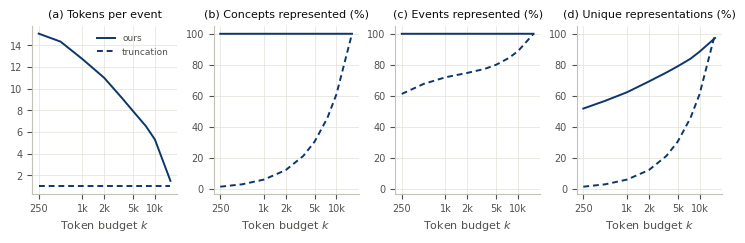

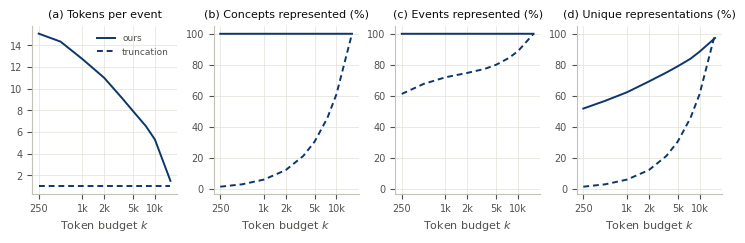

In [68]:
res.write_csv("res.csv")
plot_sweep(res, fname="k_sweep_real_data.pdf")


In [70]:

from src.graph_tokenizer_gd_tree_dev.longtail_analysis import borrowed_strength, prepare, rare_token_diagnosis


codes, pairs, tok = prepare(df_tokenized, df_vocab_freq, freq_col="len")
table, per_code = borrowed_strength(codes, pairs, tok, k=5000, rare=10)
print(table)
print(rare_token_diagnosis(codes, tok, rare=10))

NameError: name 'df_tokenized' is not defined

# find concepts with the same set of tokens but diff context tree

In [29]:
from collections import Counter, defaultdict
import re
import polars as pl
from src.graph_tokenizer_gd_tree_dev.eval import build_context_trees, _iter_contexts
from src.graph_tokenizer_gd_tree_dev.tokenizer import signature

# skip these 4 lines if `trees` is already built
ranked = pl.read_parquet(f"{config.HERODataVocabsTest.greedy_candidate_path}{LAMBDA}.parquet")["token"].to_list()
k = 5000
T = set(ranked[:k])
trees = build_context_trees(mapped_ids_overlap, adj, T, D, id_to_label)

EXCLUDE = ("?",)   # words to exclude from example labels; add more, e.g. ("substance", "product")

label = lambda x: id_to_label.get(x, x)
keep = lambda c: not any(w in label(c).lower() for w in EXCLUDE)
tag = lambda c: (m.group(1) if (m := re.search(r"\(([^()]*)\)\s*$", label(c))) else "?")

def flat_tokens(tree): return frozenset(t for ctx in _iter_contexts(tree) for t, _ in ctx.tokens)
def has_uncovered(tree): return any(ctx.uncovered for ctx in _iter_contexts(tree))
def n_contexts(tree): return sum(1 for _ in _iter_contexts(tree))
def sexpr(ctx):
    items = [label(t) for t, _ in ctx.tokens]
    if ctx.uncovered: items.append("∅")
    items += [f"{label(sub.relation)}({sexpr(sub)})" for sub in ctx.subcontexts]
    return ", ".join(items)

# counts over ALL concepts, so "unique" means unique in the whole vocabulary
flat = {c: flat_tokens(trees[c]) for c in mapped_ids_overlap}
sig = {c: signature(trees[c]) for c in mapped_ids_overlap}
flat_n = Counter(flat.values()); sig_n = Counter(sig.values())

gain = [c for c in mapped_ids_overlap if flat[c] and flat_n[flat[c]] > 1 and sig_n[sig[c]] == 1]
print(f"{len(gain)} concepts gain uniqueness from the tree; {sum(map(keep, gain))} pass the label filter")
print("by semantic tag:", Counter(tag(c) for c in gain).most_common())

# examples: built only from concepts that pass the filter
groups = defaultdict(lambda: defaultdict(list))
for c in mapped_ids_overlap:
    if flat[c] and keep(c):
        groups[flat[c]][sig[c]].append(c)

examples = [
    (fs, by_sig) for fs, by_sig in groups.items()
    if len(by_sig) >= 2 and any(sig_n[s] == 1 for s in by_sig)   # at least one tree is truly unique
]
examples.sort(key=lambda e: (
    any(has_uncovered(trees[cs[0]]) for cs in e[1].values()),   # fully covered first
    len(e[0]),                                                   # small token sets first
    max(n_contexts(trees[cs[0]]) for cs in e[1].values()),       # small trees first
))

print(f"\n{len(examples)} flat token sets with 2+ trees (after filter)")
for fs, by_sig in examples:
    print(f"\nflat token set: {sorted(label(t) for t in fs)}")
    for s, cs in by_sig.items():
        print(f"  {label(cs[0])}  ({sig_n[s]} concept(s) with this tree)")
        print(f"     ({sexpr(trees[cs[0]])})")

137 concepts gain uniqueness from the tree; 137 pass the label filter
by semantic tag: [('substance', 95), ('?', 19), ('disorder', 18), ('procedure', 5)]

75 flat token sets with 2+ trees (after filter)

flat token set: ['Vitamin E and/or vitamin E derivative (substance)']
  Alpha tocopherol acetate (substance)  (1 concept(s) with this tree)
     (Vitamin E and/or vitamin E derivative (substance), IS_MODIFICATION_OF(Vitamin E and/or vitamin E derivative (substance)))
  Alpha-tocopherol (substance)  (1 concept(s) with this tree)
     (Vitamin E and/or vitamin E derivative (substance))

flat token set: ['Carboxylic ester (substance)', 'Psychostimulant (substance)']
  Dexmethylphenidate (substance)  (1 concept(s) with this tree)
     (Carboxylic ester (substance), Psychostimulant (substance))
  Dexmethylphenidate hydrochloride (substance)  (1 concept(s) with this tree)
     (Carboxylic ester (substance), Psychostimulant (substance), IS_MODIFICATION_OF(Carboxylic ester (substance), Psychos

In [28]:
cands = ["Alcohol induced disorder co-occurrent and due to alcohol dependence (disorder)",
         "Alcohol dependence (disorder)",
         "Shock due to anaphylaxis (disorder)", "Anaphylaxis (disorder)",
         "Cardiomyopathy associated with another disorder (disorder)", "Familial cardiomyopathy (disorder)"]
lab2id = {label(c): str(c) for c in mapped_ids_overlap}
for name in cands:
    cid = lab2id.get(name, "NOT FOUND")
    kind = "EXTENSION" if cid[-3:-1] == "10" else "international ID"   # SCTID partition digits
    print(f"{cid:>20}  {kind:<16}  {name}")

     288031000119105  EXTENSION         Alcohol induced disorder co-occurrent and due to alcohol dependence (disorder)
            66590003  international ID  Alcohol dependence (disorder)
           735173007  international ID  Shock due to anaphylaxis (disorder)
            39579001  international ID  Anaphylaxis (disorder)
           195029002  international ID  Cardiomyopathy associated with another disorder (disorder)
            35728003  international ID  Familial cardiomyopathy (disorder)
